# Phần 3: Dự đoán Khách hàng Rời bỏ (Customer Churn Prediction)
Sử dụng **Random Forest Classifier** để dự đoán khả năng khách hàng rời bỏ doanh nghiệp (Churn) dựa trên:
- Tần suất mua hàng (Frequency)
- Giá trị chi tiêu (Monetary)
- Thời gian kể từ lần mua cuối (Recency)

In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
import pandas as pd
import numpy as np
import datetime as dt
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_curve, roc_auc_score
from imblearn.over_sampling import SMOTE  # Dùng để xử lý mất cân bằng dữ liệu

%matplotlib inline
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

## 1. Chuẩn bị Feature và Gán nhãn (Label)
Ta tính lại bảng RFM tương tự như Phần 2. Sau đó, định nghĩa `Is_Churn`:
- Khách hàng không có giao dịch nào trong vòng 3 tháng (90 ngày) gần nhất được coi là **Churn = 1**.
- Ngược lại là **Churn = 0**.

Tỷ lệ Churn:
Is_Churn
1    74898
0    18459
Name: count, dtype: int64


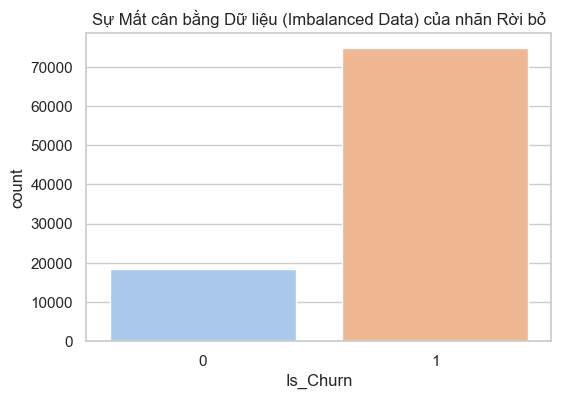

In [3]:
# Đọc dữ liệu
customers = pd.read_csv('../data/olist_customers_dataset.csv')
orders = pd.read_csv('../data/olist_orders_dataset.csv')
payments = pd.read_csv('../data/olist_order_payments_dataset.csv')
reviews = pd.read_csv('../data/olist_order_reviews_dataset.csv')
items = pd.read_csv('../data/olist_order_items_dataset.csv')

# Làm sạch bảng Orders và tính Shipping Delay
orders_delivered = orders[orders['order_status'] == 'delivered'].copy()
orders_delivered['order_purchase_timestamp'] = pd.to_datetime(orders_delivered['order_purchase_timestamp'])
orders_delivered['order_estimated_delivery_date'] = pd.to_datetime(orders_delivered['order_estimated_delivery_date'])
orders_delivered['order_delivered_customer_date'] = pd.to_datetime(orders_delivered['order_delivered_customer_date'])
orders_delivered['Shipping_Delay'] = (orders_delivered['order_delivered_customer_date'] - orders_delivered['order_estimated_delivery_date']).dt.days
orders_delivered['Shipping_Delay'] = orders_delivered['Shipping_Delay'].apply(lambda x: x if x > 0 else 0)

# Tính Review Score trung bình mỗi đơn
order_reviews = reviews.groupby('order_id')['review_score'].mean().reset_index()

# Tính Tỷ trọng phí vận chuyển (Freight Ratio)
order_items = items.groupby('order_id').agg({'freight_value': 'sum', 'price': 'sum'}).reset_index()
order_items['total_item_value'] = order_items['price'] + order_items['freight_value']
order_items['Freight_Ratio'] = order_items['freight_value'] / order_items['total_item_value']
order_items['Freight_Ratio'] = order_items['Freight_Ratio'].fillna(0)

# Merge các bảng Features
order_payments = payments.groupby('order_id')['payment_value'].sum().reset_index()
df_orders = pd.merge(orders_delivered, order_payments, on='order_id', how='inner')
df_orders = pd.merge(df_orders, order_reviews, on='order_id', how='left')
df_orders = pd.merge(df_orders, order_items[['order_id', 'Freight_Ratio']], on='order_id', how='left')

# Điền giá trị thiếu
df_orders['review_score'] = df_orders['review_score'].fillna(df_orders['review_score'].median())
df_orders['Freight_Ratio'] = df_orders['Freight_Ratio'].fillna(0)
df_orders['Shipping_Delay'] = df_orders['Shipping_Delay'].fillna(0)

df = pd.merge(df_orders, customers, on='customer_id', how='inner')

# Tính RFM và các biến phụ trợ cho mỗi Customer
snapshot_date = df['order_purchase_timestamp'].max() + dt.timedelta(days=1)
rfm = df.groupby('customer_unique_id').agg({
    'order_purchase_timestamp': lambda x: (snapshot_date - x.max()).days,
    'order_id': 'nunique',
    'payment_value': 'sum',
    'review_score': 'mean',
    'Shipping_Delay': 'mean',
    'Freight_Ratio': 'mean'
}).reset_index()

rfm.columns = ['customer_unique_id', 'Recency', 'Frequency', 'Monetary', 'Review_Score', 'Shipping_Delay', 'Freight_Ratio']

# Gán nhãn Churn (Ví dụ: Ngưỡng 90 ngày)
CHURN_THRESHOLD = 90
rfm['Is_Churn'] = np.where(rfm['Recency'] > CHURN_THRESHOLD, 1, 0)

# Kiểm tra sự mất cân bằng dữ liệu
churn_counts = rfm['Is_Churn'].value_counts()
print("Tỷ lệ Churn:")
print(churn_counts)
plt.figure(figsize=(6, 4))
sns.countplot(data=rfm, x='Is_Churn', palette='pastel')
plt.title('Sự Mất cân bằng Dữ liệu (Imbalanced Data) của nhãn Rời bỏ')
plt.show()

## 2. Huấn luyện mô hình
Vì dữ liệu Olist chủ yếu là khách hàng mua 1 lần (Recency rất cao), nhãn Churn = 1 sẽ áp đảo. Ta sử dụng `SMOTE` để sinh mẫu nhân tạo, làm cân bằng dữ liệu.
Trong phần này, ta sẽ huấn luyện:
1. **Logistic Regression (Baseline)**: Mô hình cơ sở để so sánh.
2. **Random Forest**: Mô hình chính, sử dụng `GridSearchCV` để tối ưu hóa siêu tham số (Hyperparameter Tuning).

In [4]:
X = rfm[['Frequency', 'Monetary', 'Review_Score', 'Shipping_Delay', 'Freight_Ratio']]  
y = rfm['Is_Churn']

# Chia tập Train / Test (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

try:
    smote = SMOTE(random_state=42)
    X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)
except Exception as e:
    print("SMOTE error:", e)
    X_train_resampled, y_train_resampled = X_train, y_train

print("--- HUẤN LUYỆN MÔ HÌNH ---")

lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_model.fit(X_train_resampled, y_train_resampled)
y_pred_lr = lr_model.predict(X_test)
y_prob_lr = lr_model.predict_proba(X_test)[:, 1]
print("1. Đã train xong Logistic Regression (Baseline)")

param_grid = {
    'n_estimators': [100, 200], 
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5, 10]
}

rf = RandomForestClassifier(class_weight='balanced', random_state=42)
grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, cv=5, n_jobs=-1, verbose=1)
grid_search.fit(X_train_resampled, y_train_resampled)

# Lấy mô hình tốt nhất
best_rf_model = grid_search.best_estimator_
print(f"2. Đã train xong Random Forest. Tham số tốt nhất: {grid_search.best_params_}")

# Dự đoán trên tập Test
y_pred_rf = best_rf_model.predict(X_test)
y_prob_rf = best_rf_model.predict_proba(X_test)[:, 1]

--- HUẤN LUYỆN MÔ HÌNH ---


1. Đã train xong Logistic Regression (Baseline)
Fitting 5 folds for each of 18 candidates, totalling 90 fits


2. Đã train xong Random Forest. Tham số tốt nhất: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}


## 3. Đánh giá mô hình & Ứng dụng Thực tiễn
Thực hiện đánh giá chuyên sâu qua Ma trận nhầm lẫn (Confusion Matrix), Báo cáo phân loại (Classification Report), Đường cong ROC/AUC và Feature Importance.

=== LOGISTIC REGRESSION (BASELINE) ===
              precision    recall  f1-score   support

           0       0.22      0.71      0.33      3705
           1       0.83      0.36      0.50     14967

    accuracy                           0.43     18672
   macro avg       0.53      0.54      0.42     18672
weighted avg       0.71      0.43      0.47     18672


=== RANDOM FOREST (OPTIMIZED) ===
              precision    recall  f1-score   support

           0       0.47      0.61      0.53      3705
           1       0.90      0.83      0.86     14967

    accuracy                           0.79     18672
   macro avg       0.68      0.72      0.70     18672
weighted avg       0.81      0.79      0.80     18672



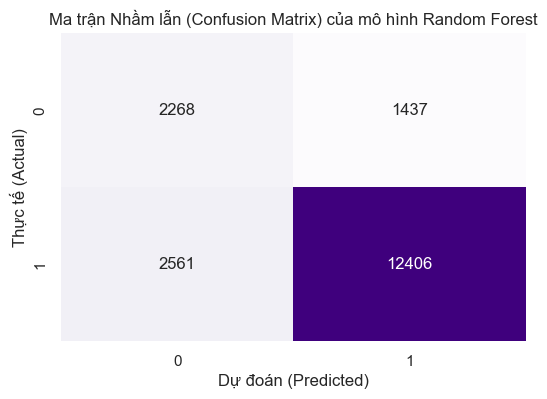

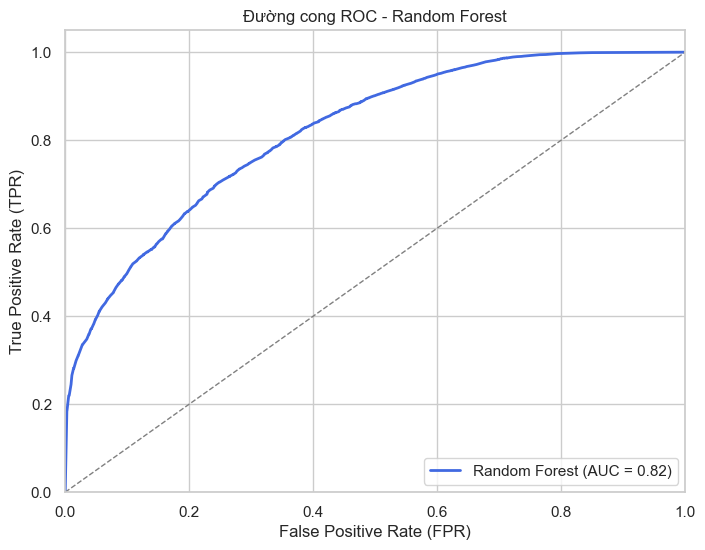

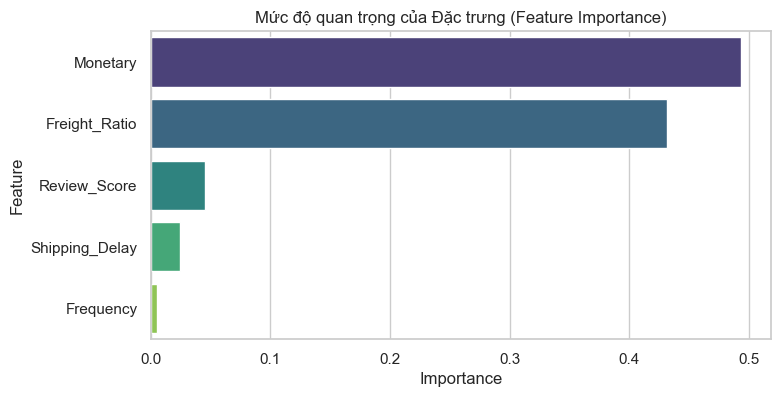

In [5]:
# 1. So sánh Báo cáo Phân loại (Classification Report)
print("=== LOGISTIC REGRESSION (BASELINE) ===")
print(classification_report(y_test, y_pred_lr))

print("\n=== RANDOM FOREST (OPTIMIZED) ===")
print(classification_report(y_test, y_pred_rf))


# 2. Ma trận Nhầm lẫn (Confusion Matrix) của Random Forest
cm = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', cbar=False)
plt.title('Ma trận Nhầm lẫn (Confusion Matrix) của mô hình Random Forest')
plt.xlabel('Dự đoán (Predicted)')
plt.ylabel('Thực tế (Actual)')
plt.show()

# 3. Đường cong ROC và AUC
fpr, tpr, thresholds = roc_curve(y_test, y_prob_rf)
roc_auc = roc_auc_score(y_test, y_prob_rf)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='royalblue', lw=2, label=f'Random Forest (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('Đường cong ROC - Random Forest')
plt.legend(loc='lower right')
plt.show()

# 4. Feature Importance
feature_importances = pd.DataFrame({'Feature': X.columns, 'Importance': best_rf_model.feature_importances_})
feature_importances = feature_importances.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(8, 4))
sns.barplot(data=feature_importances, x='Importance', y='Feature', palette='viridis')
plt.title('Mức độ quan trọng của Đặc trưng (Feature Importance)')
plt.show()


> **📌 Kết luận Mô hình:** Dựa trên Classification Report và Confusion Matrix, ta có thể thấy mô hình nhận diện tốt khách hàng có khả năng rời bỏ. Tuy nhiên, do đặc thù bộ dữ liệu Olist có rất ít khách hàng lặp lại (Frequency thường bằng 1), việc đưa `Frequency` và `Monetary` vào dự đoán Churn là một bài toán mang tính chất học thuật nhiều hơn là ứng dụng thực tế trên bộ dữ liệu này. Nếu có thêm các trường dữ liệu như thời gian truy cập app cuối cùng (Last Login), số điểm đánh giá (Review Score) hoặc khiếu nại, mô hình dự đoán Churn sẽ chính xác và mang ý nghĩa thực tiễn cao hơn.